# 4.2 Regression Models

> **Source:** [GeeksforGeeks — Linear Regression in Machine Learning](https://www.geeksforgeeks.org/machine-learning/ml-linear-regression/)

---

## What is Regression?

> **Regression** is a statistical approach to find the correlations between variables (dependent and independent).

Regression algorithms give you a **continuous output**. If you are asked to build a model that predicts a future outcome where the output is continuous, you must choose a Regression algorithm.

---

## Types of Regression

| # | Type | Description |
|---|------|-------------|
| 01 | **Simple Linear Regression** | One dependent + one independent variable — 2D space |
| 02 | **Multiple Linear Regression** | One dependent + two or more independent variables |
| 03 | **Polynomial Regression** | Fits a curved relationship using x², x³ terms |
| 04 | **Decision Tree Regressor** | Tree structure that predicts the mean of each region |
| 05 | **Random Forest Regressor** | Ensemble of many decision trees — averages predictions |

---

## Contents

| # | Topic |
|---|-------|
| 1 | Linear Regression |
| 2 | Ridge Regression (L2) |
| 3 | Lasso Regression (L1) |
| 4 | ElasticNet Regression |
| 5 | Evaluation Metrics |
| 6 | All Models Comparison |

---
## Setup — Imports & Dataset

Run this cell first. All subsequent code cells depend on the variables created here.

| Variable | What it is |
|----------|------------|
| `X_train_s`, `X_test_s` | Scaled feature matrices (mean=0, std=1) |
| `y_train`, `y_test` | Target values (median house price) |
| `X` | Full feature DataFrame — used for column names |

In [5]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context  # fix macOS SSL cert error

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)

housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Dataset : {X.shape[0]} samples, {X.shape[1]} features')
print(f'Train   : {X_train_s.shape[0]} samples')
print(f'Test    : {X_test_s.shape[0]} samples')
X.head()

Dataset : 20640 samples, 8 features
Train   : 16512 samples
Test    : 4128 samples


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


---
# 1. Linear Regression

**Definition:** Linear Regression finds a best-fit straight line through data to predict a continuous output.

---

### Key Terms

| Term | Symbol | Meaning |
|------|--------|---------|
| Independent Variable | X | Input / predictor — feature(s) you provide |
| Dependent Variable | Y | Output / target — what you want to predict |
| Slope | θ₁ | How much Y changes per unit increase in X |
| Intercept | θ₀ | Value of Y when X = 0 |

---

### Hypothesis Function

**Simple Linear Regression** (1 feature):
$$h(x) = \theta_0 + \theta_1 x$$

**Multiple Linear Regression** (k features):
$$h(x_1, \dots, x_k) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_k x_k$$

---

### Cost Function — MSE

$$J(\theta) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i)^2 \qquad \text{Residual} = y_i - \hat{y}_i$$

---

### Mathematical Example — Step by Step

#### The Goal
Find a line that predicts **house price** from **house size**:
$$\text{price} = \theta_0 + \theta_1 \times \text{size}$$

---

#### Step 1 — Data Points

| Size (sqft) | Actual Price |
|-------------|-------------|
| 1000 | 200k |
| 1500 | 300k |
| 2000 | 400k |

Plot these — they form a straight line.

---

#### Step 2 — Find θ₁ (slope) and θ₀ (intercept)

**θ₁ (slope)** = how much price goes up per sqft:
```
Every 500 sqft → price goes up 100k
Every   1 sqft → price goes up 100/500 = 0.2k

θ₁ = 0.2
```

**θ₀ (intercept)** = price when size = 0:
```
200 = θ₀ + 0.2 × 1000
200 = θ₀ + 200
θ₀  = 0
```

**Our fitted line:** price = 0 + 0.2 × size

---

#### Step 3 — Make a Prediction

**New house: size = 1800 sqft**
```
price = 0.2 × 1800 = 360k
```

---

#### Step 4 — Check Residuals (how wrong are we?)

**Residual = Actual − Predicted**

| Size | Actual | Predicted | Residual |
|------|--------|-----------|----------|
| 1000 | 200k | 0.2 × 1000 = 200k | 200 − 200 = **0** |
| 1500 | 300k | 0.2 × 1500 = 300k | 300 − 300 = **0** |
| 2000 | 400k | 0.2 × 2000 = 400k | 400 − 400 = **0** |

All residuals = 0 → perfect fit (data was perfectly linear).

---

#### Step 5 — Real Life: Messy Data

In reality data is never perfect:

| Size | Actual | Predicted | Residual |
|------|--------|-----------|----------|
| 1000 | 210k | 200k | +10k (under-predicted) |
| 1500 | 280k | 300k | −20k (over-predicted) |
| 2000 | 420k | 400k | +20k (under-predicted) |

The model finds the line that makes residuals **as small as possible** — that is minimizing MSE:
```
MSE = ((10)² + (-20)² + (20)²) / 3
    = (100 + 400 + 400) / 3
    = 900 / 3
    = 300
```
The model keeps adjusting θ₀ and θ₁ until MSE is as low as it can get.

> **Summary:** Linear Regression finds θ₀ and θ₁ so the line `y = θ₀ + θ₁x` passes as close as possible to all data points, by minimizing the squared gaps between the line and each point.

---

### Optimization — Gradient Descent

$$\theta_j := \theta_j - \alpha \frac{\partial J}{\partial \theta_j}$$

| Term | Meaning |
|------|---------|
| α (alpha) | Learning rate — controls step size |
| ∂J/∂θⱼ | Gradient — slope of the MSE curve at current position |

**Is this random?** No — every step is mathematically calculated. Only the starting point is a random guess.

---

#### The Gradient Formula for θ₁

$$\frac{\partial J}{\partial \theta_1} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}_i - y_i) \cdot x_i$$

> For each data point: multiply the error by input x → sum them all → divide by n.

---

#### Full Worked Example — Step by Step

**Our messy house price data:**

| i | Size (x) | Actual price (y) |
|---|----------|-----------------|
| 1 | 1000 | 210k |
| 2 | 1500 | 280k |
| 3 | 2000 | 420k |

**Current guess:** θ₀ = 0, θ₁ = 0.5, α = 0.0000001

---

**Step 1 — Predict using current θ₁ = 0.5**
```
ŷ₁ = 0 + 0.5 × 1000 = 500
ŷ₂ = 0 + 0.5 × 1500 = 750
ŷ₃ = 0 + 0.5 × 2000 = 1000
```

**Step 2 — Calculate error (ŷ − y) for each point**
```
error₁ = 500  − 210 = +290   (too high)
error₂ = 750  − 280 = +470   (too high)
error₃ = 1000 − 420 = +580   (too high)
```
All positive → θ₁ is too large → gradient will tell us to decrease it.

**Step 3 — Multiply each error by its x**
```
error₁ × x₁ = 290  × 1000 =   290,000
error₂ × x₂ = 470  × 1500 =   705,000
error₃ × x₃ = 580  × 2000 = 1,160,000
```

**Step 4 — Compute gradient**
```
gradient = (2/n) × Σ(errorᵢ × xᵢ)
         = (2/3) × (290,000 + 705,000 + 1,160,000)
         = (2/3) × 2,155,000
         = 1,436,667
```

**Step 5 — Update θ₁**
```
new θ₁ = old θ₁ − (α × gradient)
        = 0.5    − (0.0000001 × 1,436,667)
        = 0.5    − 0.1437
        = 0.356   ← moved closer to correct answer (0.2)
```

---

**Iteration 2 — θ₁ = 0.356:**
```
ŷ₁ = 356 → error = 356 − 210 = +146
ŷ₂ = 534 → error = 534 − 280 = +254
ŷ₃ = 712 → error = 712 − 420 = +292

gradient = (2/3) × (146×1000 + 254×1500 + 292×2000)
         = (2/3) × 1,111,000
         = 740,667   ← smaller than 1,436,667 — getting closer ✓

new θ₁ = 0.356 − (0.0000001 × 740,667) = 0.282
```

**Keep repeating...**
```
θ₁ = 0.282 → gradient shrinks further
θ₁ = 0.240 → gradient shrinks further
θ₁ = 0.210 → gradient ≈ small
θ₁ = 0.200 → gradient ≈ 0  ✓  STOP — minimum MSE found
```

---

**Why multiply error by x?**
```
Large x (2000 sqft): θ₁ change of 0.1 → prediction shifts by 200  ← big impact
Small x  (10 sqft): θ₁ change of 0.1 → prediction shifts by 1    ← tiny impact
```
Large-x points contribute more to the gradient → model adjusts more for them.

---

**What learning rate α controls:**
```
α too large  → overshoot bottom, bounce around, never converge
α too small  → correct direction but takes thousands of extra steps
α just right → reaches bottom smoothly in reasonable iterations
```

| Gradient value | Meaning | Action on θ₁ |
|---------------|---------|--------------|
| Positive (+) | θ₁ too large, on right side of curve | Decrease θ₁ |
| Negative (−) | θ₁ too small, on left side of curve | Increase θ₁ |
| Zero (0) | At the bottom — minimum MSE | Stop |

**Full loop:**
```
1. Start:     θ₁ = random guess
2. Predict:   ŷ = θ₀ + θ₁ × x
3. Error:     error = ŷ − y
4. Gradient:  (2/n) × Σ(error × x)
5. Update:    θ₁ = θ₁ − α × gradient
6. Repeat 2–5 until gradient ≈ 0
```

### 7 Key Assumptions

| # | Assumption | What it means |
|---|------------|---------------|
| 1 | **Linearity** | Relationship between X and Y is a straight line |
| 2 | **Independence of Errors** | Residuals are not correlated with each other |
| 3 | **Homoscedasticity** | Variance of residuals is constant across all X values |
| 4 | **Normality of Errors** | Residuals follow a normal distribution |
| 5 | **No Multicollinearity** | Independent variables are not highly correlated |
| 6 | **No Autocorrelation** | Errors are independent over time |
| 7 | **Additivity** | Effect of each X on Y is independent and additive |

---

### Advantages & Disadvantages

| Advantages | Disadvantages |
|------------|---------------|
| Simple and interpretable | Assumes linearity — fails on curved data |
| Computationally efficient | Sensitive to outliers |
| Good baseline model | Sensitive to multicollinearity |
| Coefficients are directly meaningful | Cannot capture complex interactions |

Feature Coefficients (scaled):
   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
  AveRooms    -0.294410
  AveOccup    -0.040829
Population    -0.002308
  HouseAge     0.122546
 AveBedrms     0.339259
    MedInc     0.854383

MAE=0.5332  RMSE=0.7456  R²=0.5758


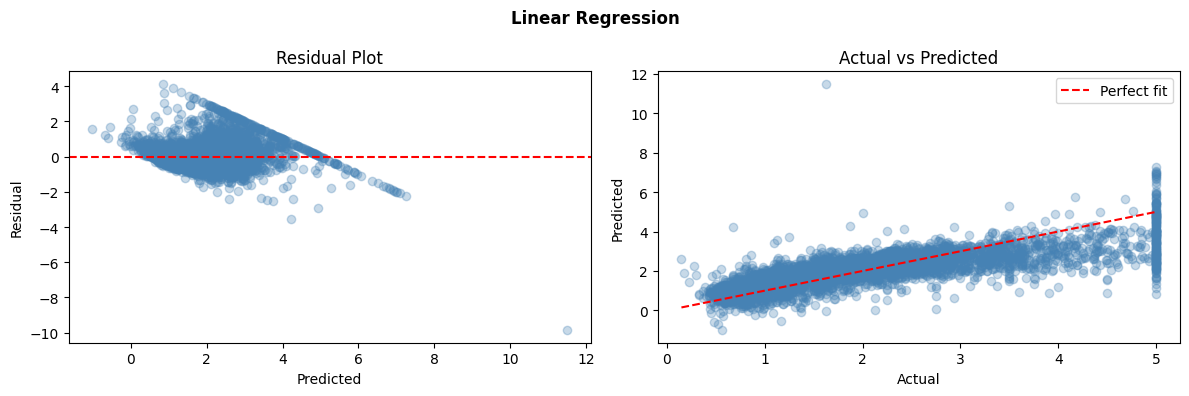

In [6]:
# ── 1. Linear Regression ──────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_s, y_train)
y_pred_lr = lr.predict(X_test_s)

# Coefficients
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_}).sort_values('Coefficient')
print('Feature Coefficients (scaled):')
print(coef_df.to_string(index=False))

# Metrics
mae  = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2   = r2_score(y_test, y_pred_lr)
print(f'\nMAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')

# Plots
residuals = y_test - y_pred_lr
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred_lr, residuals, alpha=0.3, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set(xlabel='Predicted', ylabel='Residual', title='Residual Plot')
axes[1].scatter(y_test, y_pred_lr, alpha=0.3, color='steelblue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect fit')
axes[1].set(xlabel='Actual', ylabel='Predicted', title='Actual vs Predicted')
axes[1].legend()
plt.suptitle('Linear Regression', fontweight='bold')
plt.tight_layout()
plt.show()

### Code Explanation — Linear Regression

| Code | What it does |
|------|--------------|
| `LinearRegression()` | Creates model with no regularization — plain OLS |
| `lr.fit(X_train_s, y_train)` | Finds optimal θ₀…θₙ that minimize MSE on training data |
| `lr.coef_` | The slope for each feature — how much price changes per unit |
| `lr.predict(X_test_s)` | Applies learned weights to test data |
| Residual Plot | Should look like a random cloud around 0 — no pattern means good fit |
| Actual vs Predicted | Points close to the red diagonal = accurate predictions |

---
# 2. Ridge Regression (L2 Regularization)

**Definition:** Ridge adds a penalty on the **squared values** of the coefficients to prevent overfitting. Especially useful when features are correlated (multicollinearity).

---

### Why is Ridge Used?
- Normal Linear Regression can overfit — coefficients become very large
- When features are correlated, coefficients become unstable
- Ridge **shrinks** all coefficients — reduces impact without removing any feature

---

### Cost Function

$$J(\theta) = \underbrace{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}_{\text{normal MSE}} + \underbrace{\lambda \sum_{j=1}^{p} w_j^2}_{\text{L2 penalty}}$$

| Term | Meaning |
|------|---------|
| λ (lambda / alpha) | Regularization strength — higher = more shrinkage |
| Σwⱼ² | Sum of squared weights — the penalty |
| λ = 0 | Same as plain Linear Regression |
| λ → ∞ | All coefficients → 0 |

---

### Mathematical Example — Step by Step

#### The Goal
Predict house price using two features: **size (x1)** and **age (x2)**.
After plain OLS we get: `w1 = 8, w2 = 5`, MSE = 4.0

---

#### Step 1 — Plain Linear cost (no penalty)
```
Cost = MSE + 0 × (w1² + w2²)
     = 4.0 + 0
     = 4.0
```
No constraint — weights can be as large as they want.

---

#### Step 2 — Add Ridge penalty (λ = 1)
```
Cost = MSE + λ × (w1² + w2²)
     = 4.0 + 1 × (8² + 5²)
     = 4.0 + 1 × (64 + 25)
     = 4.0 + 89
     = 93.0   ← very high! optimizer is forced to reduce w1 and w2
```

---

#### Step 3 — Optimizer finds smaller weights
```
New weights: w1 = 5, w2 = 3  (shrunk down)

Cost = 5.2 + 1 × (5² + 3²)
     = 5.2 + (25 + 9)
     = 5.2 + 34
     = 39.2   ← much lower total cost
```

---

#### Step 4 — Result

| | w1 | w2 | Both zero? |
|--|----|----|------------|
| Before Ridge | 8 | 5 | No |
| After Ridge | 5 | 3 | No — just smaller |

> **Key point:** Ridge shrinks weights but **never makes them exactly 0**. Both features stay in the model.

---

### Key Properties

| Property | Detail |
|----------|---------|
| Penalty type | L2 — squared coefficients |
| Zeros out coefficients? | **No** — shrinks toward 0, never reaches 0 |
| Feature Selection | No — keeps all features |
| Best for | Multicollinearity; when all features matter |

---

### Advantages

| Advantage | Why it matters |
|-----------|----------------|
| Handles multicollinearity | Distributes weight among correlated features |
| Reduces overfitting | Large weights are penalized |
| Stable predictions | Coefficients don't swing with small data changes |
| Always has a unique solution | Even when features are correlated |

In [8]:
# ── 2. Ridge Regression ───────────────────────────────────────────────────
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)
y_pred_ridge = ridge.predict(X_test_s)

# Compare coefficients: Linear vs Ridge
lr_base = LinearRegression().fit(X_train_s, y_train)
coef_compare = pd.DataFrame({
    'Feature'       : X.columns,
    'Linear coef'   : lr_base.coef_.round(4),
    'Ridge coef'    : ridge.coef_.round(4)
})
print('Coefficient comparison — Linear vs Ridge (alpha=1.0):')
print(coef_compare.to_string(index=False))
print('(Ridge coefs are smaller — shrunk toward 0, none are exactly 0)')

# Metrics
mae  = mean_absolute_error(y_test, y_pred_ridge)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2   = r2_score(y_test, y_pred_ridge)
print(f'\nRidge → MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')

# Effect of lambda on coefficients
alphas = [0, 0.1, 1, 10, 100]
rows = []
for a in alphas:
    m = Ridge(alpha=a).fit(X_train_s, y_train) if a > 0 else LinearRegression().fit(X_train_s, y_train)
    rows.append({'lambda': a, 'max |coef|': np.abs(m.coef_).max().round(4),
                 'R²': r2_score(y_test, m.predict(X_test_s)).round(4)})
print('\nEffect of lambda on Ridge:')
print(pd.DataFrame(rows).to_string(index=False))

Coefficient comparison — Linear vs Ridge (alpha=1.0):
   Feature  Linear coef  Ridge coef
    MedInc       0.8544      0.8543
  HouseAge       0.1225      0.1226
  AveRooms      -0.2944     -0.2942
 AveBedrms       0.3393      0.3390
Population      -0.0023     -0.0023
  AveOccup      -0.0408     -0.0408
  Latitude      -0.8969     -0.8962
 Longitude      -0.8698     -0.8691
(Ridge coefs are smaller — shrunk toward 0, none are exactly 0)

Ridge → MAE=0.5332  RMSE=0.7456  R²=0.5758

Effect of lambda on Ridge:
 lambda  max |coef|     R²
    0.0      0.8969 0.5758
    0.1      0.8969 0.5758
    1.0      0.8962 0.5758
   10.0      0.8894 0.5761
  100.0      0.8481 0.5778


### Code Explanation — Ridge Regression

| Code | What it does |
|------|--------------|
| `Ridge(alpha=1.0)` | alpha = λ. Higher value = stronger L2 penalty = more shrinkage |
| Coefficient comparison | Shows Ridge coefs are smaller than plain Linear — shrunk but none are 0 |
| Lambda effect table | As lambda increases, max coefficient gets smaller (more shrinkage) |
| `alpha=0` | Equivalent to plain LinearRegression — no penalty |
| `alpha=100` | Heavy shrinkage — all coefs very small, R² may drop (underfitting) |

---
# 3. Lasso Regression (L1 Regularization)

**Definition:** Lasso (Least Absolute Shrinkage and Selection Operator) adds a penalty on the **absolute values** of coefficients. It can shrink some weights to **exactly zero**, automatically removing useless features.

---

### Why is Lasso Used?
- When you have many features but only a few are truly useful
- **Automatically selects** important features by zeroing out the rest
- Produces simpler, more interpretable models
- Prevents overfitting by discarding irrelevant inputs entirely

---

### Cost Function

$$J(\theta) = \underbrace{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}_{\text{normal MSE}} + \underbrace{\lambda \sum_{j=1}^{p} |w_j|}_{\text{L1 penalty}}$$

| Term | Meaning |
|------|---------|
| λ (lambda / alpha) | Regularization strength |
| Σ\|wⱼ\| | Sum of absolute values of weights |

**Why does Lasso reach exactly 0 but Ridge doesn't?**
- Ridge penalty: w² — smooth curve, gently pushes toward 0, never snaps there
- Lasso penalty: |w| — sharp V-shape at 0, optimizer snaps small weights to exactly 0

---

### Mathematical Example — Step by Step

#### The Goal
Predict salary from 3 features: **experience (x1)**, **hair color (x2)**, **job level (x3)**.
After plain OLS: `w1 = 8, w2 = 0.3, w3 = 6`, MSE = 3.0

---

#### Step 1 — Compute Lasso cost (λ = 1)
```
Cost = MSE + λ × (|w1| + |w2| + |w3|)
     = 3.0 + 1 × (|8| + |0.3| + |6|)
     = 3.0 + 14.3
     = 17.3
```

---

#### Step 2 — Optimizer asks: should I zero out w2?
```
w2 = 0.3 → contributes 0.3 to the penalty
Dropping w2 saves 0.3 penalty with almost no MSE increase
→ Yes! Set w2 = 0
```

---

#### Step 3 — After Lasso optimization
```
w1 = 6.5  (useful — kept, shrunk a little)
w2 = 0.0  (useless — removed completely)
w3 = 5.1  (useful — kept, shrunk a little)

Cost = 3.4 + (|6.5| + |0| + |5.1|)
     = 3.4 + 11.6
     = 15.0   ← lower cost, w2 eliminated
```

---

#### Step 4 — Result

| Feature | Before Lasso | After Lasso | Removed? |
|---------|-------------|-------------|----------|
| experience (w1) | 8.0 | 6.5 | No — useful |
| hair color (w2) | 0.3 | **0.0** | **Yes — useless** |
| job level (w3) | 6.0 | 5.1 | No — useful |

> **Key point:** Lasso zeroed out hair color completely — the model now only uses experience and job level.

---

### What are w1, w2, w3?

They are the **coefficients (weights)** assigned to each feature in the model:

$$\text{salary} = w_0 + w_1 \times x_1 + w_2 \times x_2 + w_3 \times x_3$$

| Symbol | Feature | Value | Meaning |
|--------|---------|-------|---------|
| w1 | years of experience | 8.0 | 1 extra year → salary goes up by 8 units |
| w2 | hair color | 0.3 | hair color change → salary goes up by 0.3 units ← nearly nothing |
| w3 | job level | 6.0 | 1 extra job level → salary goes up by 6 units |

**Simple rule:**
```
Large w  → feature matters a lot   → keep it
Small w  → feature barely matters  → Lasso zeros it out
w = 0    → feature completely ignored by the model
```

**Before vs After Lasso:**
```
Before:  salary = 0 + 8.0×experience + 0.3×hair_color + 6.0×job_level
After:   salary = 0 + 6.5×experience + 0.0×hair_color + 5.1×job_level
                                            ↑
                                   removed — saves penalty cost,
                                   barely increases MSE
```

---

### Key Properties

| Property | Detail |
|----------|---------|
| Penalty type | L1 — absolute values of coefficients |
| Zeros out coefficients? | **Yes** — unimportant features hit exactly 0 |
| Feature Selection | Yes — automatic |
| Best for | High-dimensional data; many irrelevant features |

---

### Lasso vs Ridge

| | Lasso (L1) | Ridge (L2) |
|--|------------|------------|
| Penalty | λ Σ\|wⱼ\| | λ Σwⱼ² |
| Zeros out? | Yes | No |
| Feature Selection | Yes | No |
| Use When | Many irrelevant features | All features relevant, correlated |

---

### Advantages

| Advantage | Why it matters |
|-----------|----------------|
| Automatic feature selection | No manual work to remove irrelevant features |
| Sparse, interpretable model | Only important features survive |
| Reduces overfitting | Noise features eliminated entirely |
| Great for high-dimensional data | Works when features >> samples |

Coefficients — Linear vs Lasso (alpha=0.1):
   Feature  Linear coef  Lasso coef Zeroed out?
    MedInc       0.8544      0.7106          no
  HouseAge       0.1225      0.1065          no
  AveRooms      -0.2944     -0.0000         YES
 AveBedrms       0.3393      0.0000         YES
Population      -0.0023     -0.0000         YES
  AveOccup      -0.0408     -0.0000         YES
  Latitude      -0.8969     -0.0115          no
 Longitude      -0.8698     -0.0000         YES

Features removed: 5 / 8

Lasso → MAE=0.6222  RMSE=0.8244  R²=0.4814


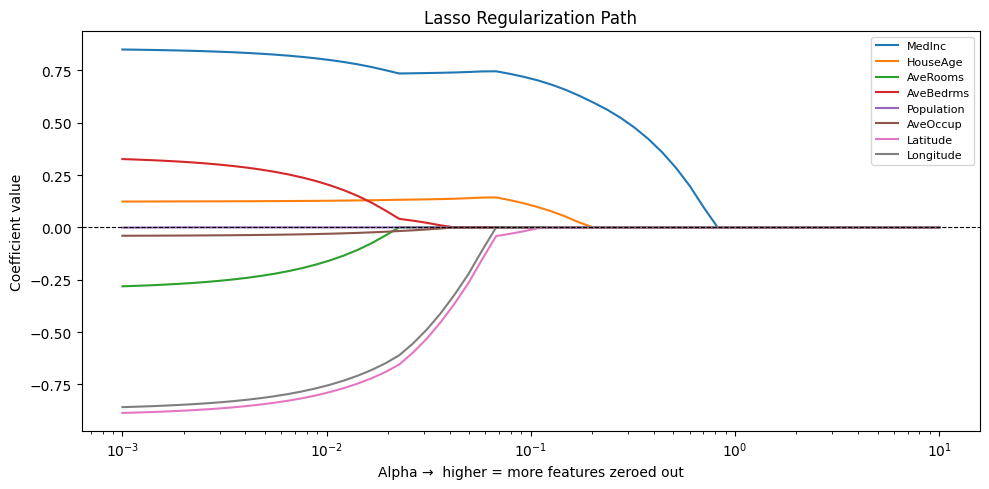

In [9]:
# ── 3. Lasso Regression ───────────────────────────────────────────────────
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train_s, y_train)
y_pred_lasso = lasso.predict(X_test_s)

# Coefficients — show which hit 0
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Linear coef': LinearRegression().fit(X_train_s, y_train).coef_.round(4),
    'Lasso coef' : lasso.coef_.round(4),
    'Zeroed out?': ['YES' if c == 0 else 'no' for c in lasso.coef_]
})
print('Coefficients — Linear vs Lasso (alpha=0.1):')
print(coef_df.to_string(index=False))
print(f'\nFeatures removed: {(lasso.coef_ == 0).sum()} / {len(lasso.coef_)}')

# Metrics
mae  = mean_absolute_error(y_test, y_pred_lasso)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2   = r2_score(y_test, y_pred_lasso)
print(f'\nLasso → MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')

# Regularization path — how coefs change as alpha increases
alphas = np.logspace(-3, 1, 60)
coefs  = np.array([Lasso(alpha=a, max_iter=10000).fit(X_train_s, y_train).coef_ for a in alphas])

fig, ax = plt.subplots(figsize=(10, 5))
for i, name in enumerate(X.columns):
    ax.plot(alphas, coefs[:, i], label=name)
ax.set_xscale('log')
ax.set_xlabel('Alpha →  higher = more features zeroed out')
ax.set_ylabel('Coefficient value')
ax.set_title('Lasso Regularization Path')
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Code Explanation — Lasso Regression

| Code | What it does |
|------|--------------|
| `Lasso(alpha=0.1)` | alpha = λ. Higher value = more features zeroed out |
| `max_iter=10000` | Lasso needs more iterations to converge — increase if you see convergence warnings |
| `Zeroed out?` column | Shows which features Lasso removed completely |
| `(lasso.coef_ == 0).sum()` | Counts how many features were eliminated |
| Regularization path plot | Each line = one feature's coefficient as alpha increases. Lines that hit 0 = features Lasso removes. Features that stay non-zero longest = most important |

---
# 4. ElasticNet Regression

**Definition:** ElasticNet combines both **L1 (Lasso)** and **L2 (Ridge)** penalties — feature selection from Lasso + stability for correlated features from Ridge.

---

### Why is ElasticNet Used?
- Lasso struggles with **correlated features** — it randomly picks one and drops the rest
- Ridge doesn't do **feature selection** — keeps everything
- ElasticNet does both: selects features AND handles correlated groups fairly

---

### Cost Function

$$J(\theta) = \frac{1}{n}\sum(y_i - \hat{y}_i)^2 + \lambda \left[ \underbrace{\alpha \sum_{j}|w_j|}_{\text{L1 part}} + \underbrace{(1-\alpha)\sum_{j}w_j^2}_{\text{L2 part}} \right]$$

| Term | Meaning |
|------|---------|
| λ (lambda) | Overall regularization strength |
| α (l1_ratio) | 0 = pure Ridge, 1 = pure Lasso, 0.5 = equal mix |

---

### Mathematical Example — Step by Step

#### The Goal
Predict exam score from 4 features:
- **x1 = study hours** (useful)
- **x2 = sleep hours** (useful, but correlated with x1)
- **x3 = hair length** (useless)
- **x4 = shoe size** (useless)

After plain OLS: `w1=7, w2=6, w3=0.4, w4=0.2`, MSE=2.0, λ=1, l1_ratio=0.5

---

#### Step 1 — Compute L1 part
```
L1 part = l1_ratio × (|w1| + |w2| + |w3| + |w4|)
        = 0.5 × (7 + 6 + 0.4 + 0.2)
        = 0.5 × 13.6
        = 6.8
```

---

#### Step 2 — Compute L2 part
```
L2 part = (1 - l1_ratio) × (w1² + w2² + w3² + w4²)
        = 0.5 × (49 + 36 + 0.16 + 0.04)
        = 0.5 × 85.2
        = 42.6
```

---

#### Step 3 — Total cost
```
Total Cost = MSE + λ × (L1 part + L2 part)
           = 2.0 + 1 × (6.8 + 42.6)
           = 2.0 + 49.4
           = 51.4
```

---

#### Step 4 — After ElasticNet optimization
```
w1 = 5.5  (useful — kept, shrunk by L2)
w2 = 4.8  (useful & correlated — L2 keeps BOTH, unlike Lasso)
w3 = 0.0  (useless — zeroed by L1)
w4 = 0.0  (useless — zeroed by L1)
```

---

#### Step 5 — Why ElasticNet beats pure Lasso here
```
Pure Lasso result:    w1=9.1, w2=0.0  ← drops one correlated feature randomly
ElasticNet result:    w1=5.5, w2=4.8  ← keeps both, shrinks both fairly
```

Lasso sees x1 and x2 as redundant (correlated) and drops one.
ElasticNet's L2 part recognizes both contribute and keeps them.

---

#### Step 6 — Result summary

| Feature | Before | After ElasticNet | Removed? |
|---------|--------|-----------------|----------|
| study hours (w1) | 7.0 | 5.5 | No |
| sleep hours (w2) | 6.0 | 4.8 | No — correlated but kept |
| hair length (w3) | 0.4 | **0.0** | **Yes** |
| shoe size (w4) | 0.2 | **0.0** | **Yes** |

---

### Key Properties

| Property | Detail |
|----------|---------|
| Penalty type | L1 + L2 combined |
| Zeros out coefficients? | Yes (via L1 part) |
| Feature Selection | Yes |
| Handles Multicollinearity | Yes (via L2 part) |
| l1_ratio = 0 | Pure Ridge — no zeros |
| l1_ratio = 1 | Pure Lasso — most zeros |

---

### Full Comparison

| | Linear | Ridge (L2) | Lasso (L1) | Elastic Net |
|--|--------|------------|------------|-------------|
| Penalty | None | λ Σwⱼ² | λ Σ\|wⱼ\| | L1 + L2 |
| Zeros out? | No | No | Yes | Yes |
| Feature Selection | No | No | Yes | Yes |
| Multicollinearity | Fails | Handles well | Handles poorly | Handles well |
| Use When | Clean data | All features matter | Many irrelevant | Many correlated |

---

### Advantages

| Advantage | Why it matters |
|-----------|----------------|
| Best of both worlds | Selection (Lasso) + stability for correlated features (Ridge) |
| Fair to correlated features | Keeps both correlated features, unlike Lasso |
| Flexible | l1_ratio tunes how much selection vs. shrinkage |
| Robust | Works well when features > samples |

In [10]:
# ── 4. ElasticNet Regression ──────────────────────────────────────────────
enet = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
enet.fit(X_train_s, y_train)
y_pred_enet = enet.predict(X_test_s)

# Side-by-side coefficient comparison
lr_c  = LinearRegression().fit(X_train_s, y_train).coef_
rd_c  = Ridge(alpha=0.1).fit(X_train_s, y_train).coef_
ls_c  = Lasso(alpha=0.1, max_iter=10000).fit(X_train_s, y_train).coef_
en_c  = enet.coef_

coef_all = pd.DataFrame({
    'Feature'    : X.columns,
    'Linear'     : lr_c.round(3),
    'Ridge'      : rd_c.round(3),
    'Lasso'      : ls_c.round(3),
    'ElasticNet' : en_c.round(3)
})
print('Coefficient comparison (all 4 models, alpha=0.1):')
print(coef_all.to_string(index=False))

# Effect of l1_ratio
print('\nEffect of l1_ratio on ElasticNet (alpha=0.1):')
for ratio in [0.0, 0.25, 0.5, 0.75, 1.0]:
    m = ElasticNet(alpha=0.1, l1_ratio=ratio, max_iter=10000).fit(X_train_s, y_train)
    zeros = (m.coef_ == 0).sum()
    r2_val = r2_score(y_test, m.predict(X_test_s))
    print(f'  l1_ratio={ratio:.2f} → zeros: {zeros}/8 features,  R²: {r2_val:.4f}')

# Metrics
mae  = mean_absolute_error(y_test, y_pred_enet)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_enet))
r2   = r2_score(y_test, y_pred_enet)
print(f'\nElasticNet → MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}')

Coefficient comparison (all 4 models, alpha=0.1):
   Feature  Linear  Ridge  Lasso  ElasticNet
    MedInc   0.854  0.854  0.711       0.714
  HouseAge   0.123  0.123  0.106       0.137
  AveRooms  -0.294 -0.294 -0.000      -0.000
 AveBedrms   0.339  0.339  0.000       0.000
Population  -0.002 -0.002 -0.000       0.000
  AveOccup  -0.041 -0.041 -0.000      -0.000
  Latitude  -0.897 -0.897 -0.011      -0.176
 Longitude  -0.870 -0.870 -0.000      -0.133

Effect of l1_ratio on ElasticNet (alpha=0.1):


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.436e+03, tolerance: 2.207e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


  l1_ratio=0.00 → zeros: 0/8 features,  R²: 0.5557
  l1_ratio=0.25 → zeros: 2/8 features,  R²: 0.5376
  l1_ratio=0.50 → zeros: 4/8 features,  R²: 0.5148
  l1_ratio=0.75 → zeros: 5/8 features,  R²: 0.4885
  l1_ratio=1.00 → zeros: 5/8 features,  R²: 0.4814

ElasticNet → MAE=0.5970  RMSE=0.7974  R²=0.5148


### Code Explanation — ElasticNet Regression

| Code | What it does |
|------|--------------|
| `ElasticNet(alpha=0.1, l1_ratio=0.5)` | alpha=λ (overall strength), l1_ratio=α (mix: 0.5 = 50% Lasso + 50% Ridge) |
| Coefficient comparison table | Shows all 4 models side-by-side — Ridge never zeros, Lasso/ElasticNet can |
| l1_ratio loop | `l1_ratio=0.0` behaves like Ridge (0 zeros), `l1_ratio=1.0` behaves like Lasso (most zeros) |
| `zeros` count | How many features ElasticNet removed — increases as l1_ratio increases |

---
# 5. Evaluation Metrics

How do we measure how well a regression model performs?

---

## 1. MAE — Mean Absolute Error

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

### Why is it used?
- You want to know the **average mistake** your model makes in the same units as your target
- Every error is treated equally — a 10k error counts exactly as 10, not more, not less
- Easy to explain to non-technical people: "our model is off by X on average"

### Example
Predict house prices:

| House | Actual | Predicted | Error | |Error|| 
|-------|--------|-----------|-------|--------|
| 1 | 200k | 210k | −10k | 10k |
| 2 | 300k | 280k | +20k | 20k |
| 3 | 400k | 390k | +10k | 10k |

```
MAE = (10 + 20 + 10) / 3 = 40 / 3 = 13.3k
→ On average our model is off by 13.3k
```

### Where it is used
- **Real estate** — average price prediction error in dollars
- **Demand forecasting** — average units off per day
- When you want errors in the **same unit as the output** and no outlier sensitivity

---

## 2. MSE — Mean Squared Error

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

### Why is it used?
- **Penalizes large errors much more** than small ones (because of squaring)
- A 20k error is not 2× bad — it is 4× bad (20² = 400 vs 10² = 100)
- Used internally as the **cost function** that the model minimizes during training

### Example
Same house prices:

| House | Error | Error² |
|-------|-------|--------|
| 1 | 10k | 100 |
| 2 | 20k | 400 |
| 3 | 10k | 100 |

```
MSE = (100 + 400 + 100) / 3 = 600 / 3 = 200

Notice: house 2 (error=20) contributes 400 — 4× more than houses with error=10
→ MSE punishes that big mistake heavily
```

### Where it is used
- **Model training** — gradient descent minimizes MSE
- When **large errors are very costly** and you want to penalize them hard
- Finance, safety-critical systems

---

## 3. RMSE — Root Mean Squared Error

$$\text{RMSE} = \sqrt{\text{MSE}}$$

### Why is it used?
- MSE is in **squared units** (k²) — hard to interpret
- RMSE brings it back to **original units** (k) like MAE
- Still penalizes large errors more than MAE (inherited from MSE)
- Most commonly reported metric in papers and competitions

### Example
```
MSE  = 200  (units = k²  ← not meaningful)
RMSE = √200 = 14.1k  (units = k  ← meaningful: off by 14.1k on average)
```

Compared to MAE = 13.3k:
```
RMSE (14.1k) > MAE (13.3k)
→ always true when errors are unequal
→ the gap tells you how much large errors are hurting your model
```

### Where it is used
- **Most regression problems** — default metric in sklearn, Kaggle competitions
- Weather forecasting, stock prediction, energy consumption
- When you want same units as output AND care about large errors

---

## 4. R² — Coefficient of Determination

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2} = 1 - \frac{SS_{res}}{SS_{tot}}$$

### Why is it used?
- Tells you **how much better** your model is compared to just predicting the mean every time
- Scale-independent — works across different datasets and units
- R²=0.85 means: "model explains 85% of the variation in house prices"

### Example
```
Mean house price ȳ = 300k

SS_tot = (200-300)² + (300-300)² + (400-300)²
       = 10000 + 0 + 10000 = 20000   ← total variance in data

SS_res = (200-210)² + (300-280)² + (400-390)²
       = 100 + 400 + 100 = 600       ← variance our model didn't explain

R² = 1 - 600/20000 = 1 - 0.03 = 0.97
→ model explains 97% of the variance ✓
```

### Interpreting R²
```
R² = 1.0  → perfect predictions
R² = 0.97 → excellent
R² = 0.70 → decent
R² = 0.0  → model is no better than predicting the mean
R² < 0    → model is WORSE than predicting the mean (very bad)
```

### Where it is used
- **Comparing models** — which model explains more variance?
- **Feature selection** — does adding this feature improve R²?
- Science and research — how well does X explain Y?

---

## 5. MAPE — Mean Absolute Percentage Error

$$\text{MAPE} = \frac{1}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat{y}_i}{y_i}\right| \times 100$$

### Why is it used?
- Expresses error as a **percentage** of the actual value — scale-independent
- Easy to communicate: "our model is off by 5% on average"
- Useful when comparing models across **different scales** (predicting both cheap and expensive items)

### Example
```
House 1: actual=200k, predicted=210k → |200-210|/200 × 100 = 5%
House 2: actual=300k, predicted=280k → |300-280|/300 × 100 = 6.7%
House 3: actual=400k, predicted=390k → |400-390|/400 × 100 = 2.5%

MAPE = (5 + 6.7 + 2.5) / 3 = 4.7%
→ on average the model is off by 4.7% of the actual price
```

### Where it is used
- **Retail & supply chain** — forecast accuracy in %
- **Finance** — % error in revenue forecasts
- When stakeholders understand % better than raw numbers
- **Avoid** when actual values can be 0 (division by zero)

---

## Summary Table

| Metric | Formula | Units | Outlier Sensitive | Best for |
|--------|---------|-------|-------------------|---------|
| MAE | mean(\|y−ŷ\|) | Same as y | No | Interpretable average error |
| MSE | mean((y−ŷ)²) | y² | Yes | Model training, penalizing large errors |
| RMSE | √MSE | Same as y | Yes | Most regression problems |
| R² | 1−SS_res/SS_tot | None (0–1) | Moderate | Comparing models, % variance explained |
| MAPE | mean(\|y−ŷ\|/\|y\|)×100 | % | No | % error, cross-scale comparison |

In [11]:
# ── 5. Evaluation Metrics — Small Examples ────────────────────────────────
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Same 3 house prices used in the theory
actual    = np.array([200, 300, 400])   # actual prices (k)
predicted = np.array([210, 280, 390])   # model predictions (k)

mae  = mean_absolute_error(actual, predicted)
mse  = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)
r2   = r2_score(actual, predicted)
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print('=== Metrics on House Price Example ===')
print(f'MAE  = {mae:.2f}k   → model is off by {mae:.1f}k on average')
print(f'MSE  = {mse:.2f}    → squared error (not interpretable directly)')
print(f'RMSE = {rmse:.2f}k  → like MAE but penalizes large errors more')
print(f'R²   = {r2:.4f}    → model explains {r2*100:.1f}% of variance')
print(f'MAPE = {mape:.2f}%  → model is off by {mape:.1f}% on average')

print()
print('--- Why RMSE > MAE ---')
print(f'MAE  = {mae:.2f}k  (all errors equal weight)')
print(f'RMSE = {rmse:.2f}k  (house 2 error=20 pulls this up more)')
print(f'Gap  = {rmse-mae:.2f}k  ← caused by the large 20k error on house 2')

print()
print('--- Effect of one big outlier ---')
predicted_outlier = np.array([210, 280, 600])   # house 3 way off
print(f'Normal predictions: RMSE={np.sqrt(mean_squared_error(actual, predicted)):.1f}k,  MAE={mean_absolute_error(actual, predicted):.1f}k')
print(f'With outlier (600): RMSE={np.sqrt(mean_squared_error(actual, predicted_outlier)):.1f}k,  MAE={mean_absolute_error(actual, predicted_outlier):.1f}k')
print('→ RMSE jumps much more than MAE — it is more sensitive to outliers')

=== Metrics on House Price Example ===
MAE  = 13.33k   → model is off by 13.3k on average
MSE  = 200.00    → squared error (not interpretable directly)
RMSE = 14.14k  → like MAE but penalizes large errors more
R²   = 0.9700    → model explains 97.0% of variance
MAPE = 4.72%  → model is off by 4.7% on average

--- Why RMSE > MAE ---
MAE  = 13.33k  (all errors equal weight)
RMSE = 14.14k  (house 2 error=20 pulls this up more)
Gap  = 0.81k  ← caused by the large 20k error on house 2

--- Effect of one big outlier ---
Normal predictions: RMSE=14.1k,  MAE=13.3k
With outlier (600): RMSE=116.2k,  MAE=76.7k
→ RMSE jumps much more than MAE — it is more sensitive to outliers


### Code Explanation — Evaluation Metrics

| Code | What it does |
|------|--------------|
| `mean_absolute_error` | Computes MAE — average of absolute differences |
| `mean_squared_error` | Computes MSE — average of squared differences |
| `np.sqrt(mse)` | RMSE — sklearn has no direct function, so we take √MSE manually |
| `r2_score` | Computes R² — proportion of variance explained |
| `np.abs((actual-predicted)/actual)*100` | MAPE — percentage error for each point, then averaged |

**What to observe:**
- RMSE is always ≥ MAE — the gap grows when you have large errors
- The outlier test shows RMSE jumps much more than MAE — confirming RMSE is outlier-sensitive
- R² close to 1 = good fit, even on this tiny 3-point example

---
# 6. All Models Comparison

Run all 4 models on the same dataset and compare their metrics side-by-side.

All Models — Metric Comparison:
        Model    MAE   RMSE     R²  MAPE%  Zero coefs
       Linear 0.5332 0.7456 0.5758  31.95           0
Ridge (λ=1.0) 0.5332 0.7456 0.5758  31.95           0
Lasso (λ=0.1) 0.6222 0.8244 0.4814  39.97           5
   ElasticNet 0.5970 0.7974 0.5148  37.68           4


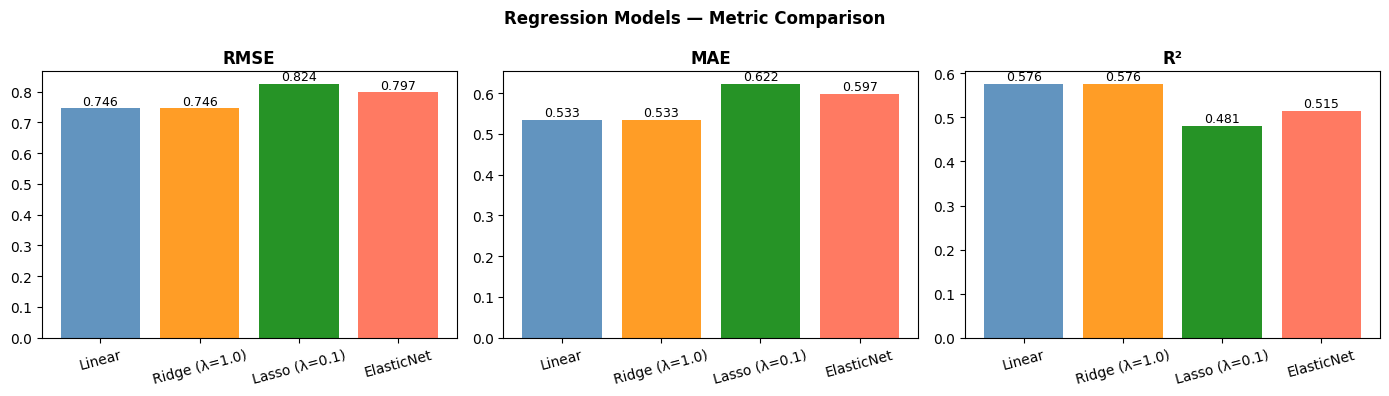

In [12]:
# ── 6. All Models Comparison ──────────────────────────────────────────────
models = {
    'Linear'        : LinearRegression(),
    'Ridge (λ=1.0)' : Ridge(alpha=1.0),
    'Lasso (λ=0.1)' : Lasso(alpha=0.1, max_iter=10000),
    'ElasticNet'    : ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
}

rows = []
for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred  = model.predict(X_test_s)
    zeros = int((model.coef_ == 0).sum())
    rows.append({
        'Model'   : name,
        'MAE'     : round(mean_absolute_error(y_test, pred), 4),
        'RMSE'    : round(np.sqrt(mean_squared_error(y_test, pred)), 4),
        'R²'      : round(r2_score(y_test, pred), 4),
        'MAPE%'   : round(np.mean(np.abs((y_test - pred) / y_test)) * 100, 2),
        'Zero coefs': zeros
    })

results_df = pd.DataFrame(rows)
print('All Models — Metric Comparison:')
print(results_df.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['steelblue', 'darkorange', 'green', 'tomato']
for ax, metric in zip(axes, ['RMSE', 'MAE', 'R²']):
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors, alpha=0.85)
    ax.set_title(metric, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Regression Models — Metric Comparison', fontweight='bold')
plt.tight_layout()
plt.show()

### Code Explanation — All Models Comparison

| Code | What it does |
|------|--------------|
| `models` dict | Stores all 4 models with their names — loop trains each one |
| `Zero coefs` column | How many features each model removed (only Lasso/ElasticNet can be > 0) |
| Bar chart | Visual comparison — lower RMSE/MAE = better, higher R² = better |

**What to observe:**
- All 4 models perform similarly here — the California housing dataset is well-conditioned
- Regularization matters more on noisy or high-dimensional datasets
- Ridge/Lasso/ElasticNet won't always beat Linear — they help most when overfitting is a problem

- lasso - https://www.geeksforgeeks.org/machine-learning/implementation-of-lasso-regression-from-scratch-using-python/
- ridge - https://www.geeksforgeeks.org/machine-learning/implementation-of-ridge-regression-from-scratch-using-python/
- elastic net - https://www.geeksforgeeks.org/machine-learning/implementation-of-elastic-net-regression-from-scratch/
- mse - https://www.geeksforgeeks.org/python/python-mean-squared-error/
- mae - https://www.geeksforgeeks.org/python/how-to-calculate-mean-absolute-error-in-python/
- rmse - https://www.geeksforgeeks.org/r-language/root-mean-square-error-in-r-programming/
- r squared - https://www.geeksforgeeks.org/maths/r-squared/
- adjusted r sqr - https://www.geeksforgeeks.org/machine-learning/ml-adjusted-r-square-in-regression-analysis/